# Tutorial Part 3 — fairkl API & Keras Integration

This tutorial walks through the `fairkl` model API and its Keras
building blocks: losses, metrics, and kernel layers.

**Outline**

1. `FairKernelRidge` model API
2. `CKALoss` and `CKAMetric` — standard Keras classes
3. Kernel layers — `RBFKernelLayer`, `RFFLayer`
4. Model serialization via `get_config`
5. Warm-started Pareto sweep
6. Canonical plot — fairness vs accuracy

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import keras.ops as ops
import matplotlib.pyplot as plt
import numpy as np

import fairkl
from fairkl.layers import RBFKernelLayer, RFFLayer
from fairkl.metrics.cka import CKALoss, CKAMetric, cka_rbf
from fairkl.models import FairKernelRidge
from _style import SCATTER_KW, style_ax

## Same Synthetic Data

In [2]:
rng = np.random.default_rng(0)
n = 200
x = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x, q]).astype("float32")
y = (np.sin(x.ravel()) + 3.0 * q.ravel() + 0.3 * rng.standard_normal(n)).astype(
    "float32"
)

---
## 1  The `FairKernelRidge` Model API

### 1.1  Standard KRR (μ = 0)

With `mu=0`, `fit()` uses the **exact closed-form** Cholesky solver —
`epochs` and `lr` are ignored.

In [3]:
model_std = FairKernelRidge(sigma=1.0, lam=0.01, mu=0.0, sigma_q=1.0)
model_std.fit(X, y)

y_std = np.array(model_std.predict(X)).ravel()
mse_std = float(np.mean((y_std - y) ** 2))
cka_std = float(cka_rbf(y_std.reshape(-1, 1).astype("float32"), q))
print(f"Standard KRR:  MSE = {mse_std:.4f},  CKA = {cka_std:.4f}")

Standard KRR:  MSE = 0.0742,  CKA = 0.6467


### 1.2  Inspecting model internals

`get_alpha()` returns the dual coefficient vector $\alpha$ and
`get_kernel_matrix(X)` returns the cross-kernel $K(X, X_\text{train})$.

In [4]:
alpha = np.array(model_std.get_alpha())
print(f"alpha shape: {alpha.shape},  ||alpha|| = {np.linalg.norm(alpha):.4f}")

K_cross = np.array(model_std.get_kernel_matrix(X[:5]))
print(f"K(X[:5], X_train) shape: {K_cross.shape}")

alpha shape: (200, 1),  ||alpha|| = 385.1943


K(X[:5], X_train) shape: (5, 200)


### 1.3  Fair KRR (μ > 0)

With `mu > 0` and a sensitive attribute `q`, `fit()` uses gradient
descent (Adam) warm-started from the exact solution.

In [5]:
model_fair = FairKernelRidge(sigma=1.0, lam=0.01, mu=10.0, sigma_q=1.0)
model_fair.fit(X, y, q=q, epochs=200, lr=0.005)

y_fair = np.array(model_fair.predict(X)).ravel()
mse_fair = float(np.mean((y_fair - y) ** 2))
cka_fair = float(cka_rbf(y_fair.reshape(-1, 1).astype("float32"), q))
print(f"Fair KRR (μ=10):  MSE = {mse_fair:.4f},  CKA = {cka_fair:.4f}")

Fair KRR (μ=10):  MSE = 2.1113,  CKA = 0.1912


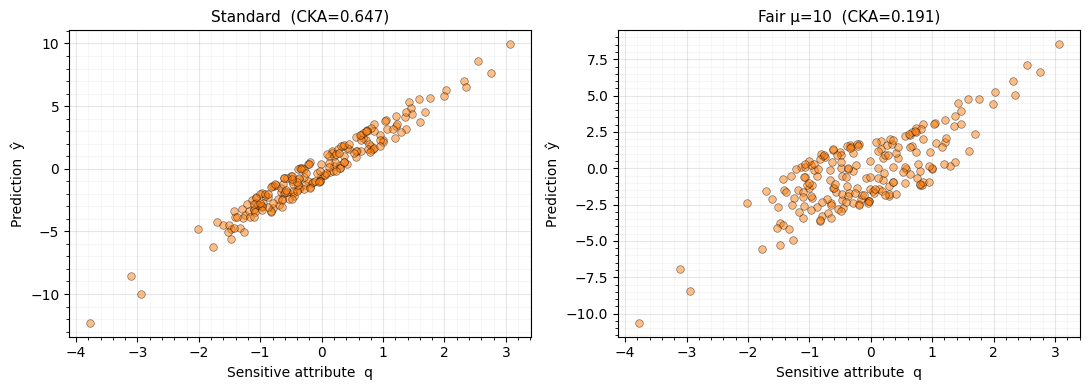

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, yh, title in zip(
    axes,
    [y_std, y_fair],
    [f"Standard  (CKA={cka_std:.3f})", f"Fair μ=10  (CKA={cka_fair:.3f})"],
):
    ax.scatter(q.ravel(), yh, c="C1", **SCATTER_KW)
    ax.set_xlabel("Sensitive attribute  q")
    ax.set_ylabel("Prediction  ŷ")
    ax.set_title(title, fontsize=11)
    style_ax(ax)
plt.tight_layout()
plt.show()

---
## 2  `CKALoss` and `CKAMetric`

These are standard Keras `Loss` and `Metric` subclasses.  They accept
`(y_true, y_pred)` where `y_true` = sensitive attribute and `y_pred` =
model output.

### 2.1  `CKALoss`

In [7]:
loss_fn = CKALoss(sigma_f=1.0, sigma_q=1.0)

# Call on our predictions — should match cka_rbf
loss_std = float(loss_fn(q, y_std.reshape(-1, 1).astype("float32")))
loss_fair = float(loss_fn(q, y_fair.reshape(-1, 1).astype("float32")))

cka_std_check = float(cka_rbf(y_std.reshape(-1, 1).astype("float32"), q))
cka_fair_check = float(cka_rbf(y_fair.reshape(-1, 1).astype("float32"), q))

print(f"CKALoss(std)  = {loss_std:.4f}   vs   cka_rbf = {cka_std_check:.4f}")
print(f"CKALoss(fair) = {loss_fair:.4f}   vs   cka_rbf = {cka_fair_check:.4f}")

CKALoss(std)  = 0.6467   vs   cka_rbf = 0.6467
CKALoss(fair) = 0.1912   vs   cka_rbf = 0.1912


### 2.2  `CKAMetric`

The metric accumulates HSIC components across batches and computes CKA
at `result()` time.

In [8]:
metric = CKAMetric(sigma_f=1.0, sigma_q=1.0)

# Simulate two batches
batch1_pred = y_std[:100].reshape(-1, 1).astype("float32")
batch1_q = q[:100]
batch2_pred = y_std[100:].reshape(-1, 1).astype("float32")
batch2_q = q[100:]

metric.update_state(batch1_q, batch1_pred)
print(f"After batch 1:  CKA = {float(metric.result()):.4f}")

metric.update_state(batch2_q, batch2_pred)
print(f"After batch 2:  CKA = {float(metric.result()):.4f}")

metric.reset_state()
print(f"After reset:    CKA = {float(metric.result()):.4f}")

After batch 1:  CKA = 0.6540
After batch 2:  CKA = 0.6447
After reset:    CKA = 0.0000


---
## 3  Kernel Layers

`fairkl` provides Keras layers that wrap kernel computations.
These are composable building blocks for custom architectures.

### 3.1  `RBFKernelLayer` — optionally trainable bandwidth

In [9]:
rbf_layer = RBFKernelLayer(sigma_init=1.0, trainable_sigma=True)
K_layer = np.array(rbf_layer(X))
K_prim = np.array(fairkl.rbf_kernel(X, sigma=1.0))

diff = float(np.max(np.abs(K_layer - K_prim)))
print(f"Max |K_layer - K_primitive| = {diff:.2e}  (should be ~0)")
sigma_val = float(ops.exp(rbf_layer.log_sigma))
print(
    f"Trainable sigma: log_sigma = {float(rbf_layer.log_sigma):.4f} -> sigma = {sigma_val:.4f}"
)

Max |K_layer - K_primitive| = 0.00e+00  (should be ~0)
Trainable sigma: log_sigma = 0.0000 -> sigma = 1.0000


### 3.2  `RFFLayer` — Random Fourier Features

RFF (D=500):  relative error = 0.1245


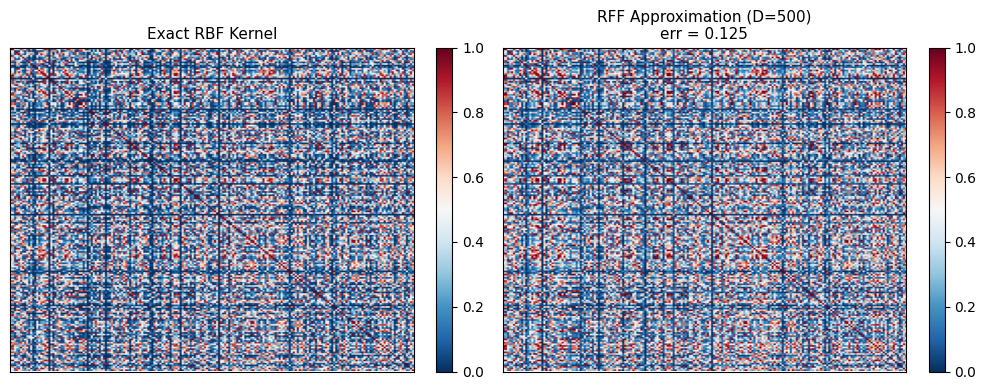

In [10]:
rff_layer = RFFLayer(n_features=500, sigma_init=1.0, seed=42)
Z_rff = np.array(rff_layer(X))
K_rff = Z_rff @ Z_rff.T

err = np.linalg.norm(K_prim - K_rff) / np.linalg.norm(K_prim)
print(f"RFF (D=500):  relative error = {err:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(K_prim, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
axes[0].set_title("Exact RBF Kernel", fontsize=11)
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(K_rff, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
axes[1].set_title(f"RFF Approximation (D=500)\nerr = {err:.3f}", fontsize=11)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

---
## 4  Model Serialization

`FairKernelRidge` implements `get_config()` for Keras serialization.

In [11]:
config = model_fair.get_config()
print("Model config:")
for k, v in config.items():
    if k != "name":
        print(f"  {k}: {v}")

Model config:
  trainable: True
  dtype: {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}
  sigma: 1.0
  lam: 0.01
  mu: 10.0
  sigma_q: 1.0
  kernel: rbf
  solver: cholesky


---
## 5  Warm-Started Pareto Sweep

We sweep $\mu$ and record MSE + CKA.  Each model is independently
trained (the `FairKernelRidge` model warm-starts from the exact
solution internally).

In [12]:
mus = [0, 1, 5, 10, 20]
mse_list, cka_list = [], []

for mu in mus:
    model = FairKernelRidge(sigma=1.0, lam=0.01, mu=mu, sigma_q=1.0)
    model.fit(X, y, q=q, epochs=200, lr=0.005)
    yh = np.array(model.predict(X)).ravel()
    mse = float(np.mean((yh - y) ** 2))
    cka_val = float(cka_rbf(yh.reshape(-1, 1).astype("float32"), q))
    mse_list.append(mse)
    cka_list.append(cka_val)
    print(f"μ = {mu:5.1f}   MSE = {mse:.3f}   CKA = {cka_val:.3f}")

μ =   0.0   MSE = 0.074   CKA = 0.647


μ =   1.0   MSE = 0.337   CKA = 0.626


μ =   5.0   MSE = 1.018   CKA = 0.350


μ =  10.0   MSE = 2.111   CKA = 0.191


μ =  20.0   MSE = 3.809   CKA = 0.075


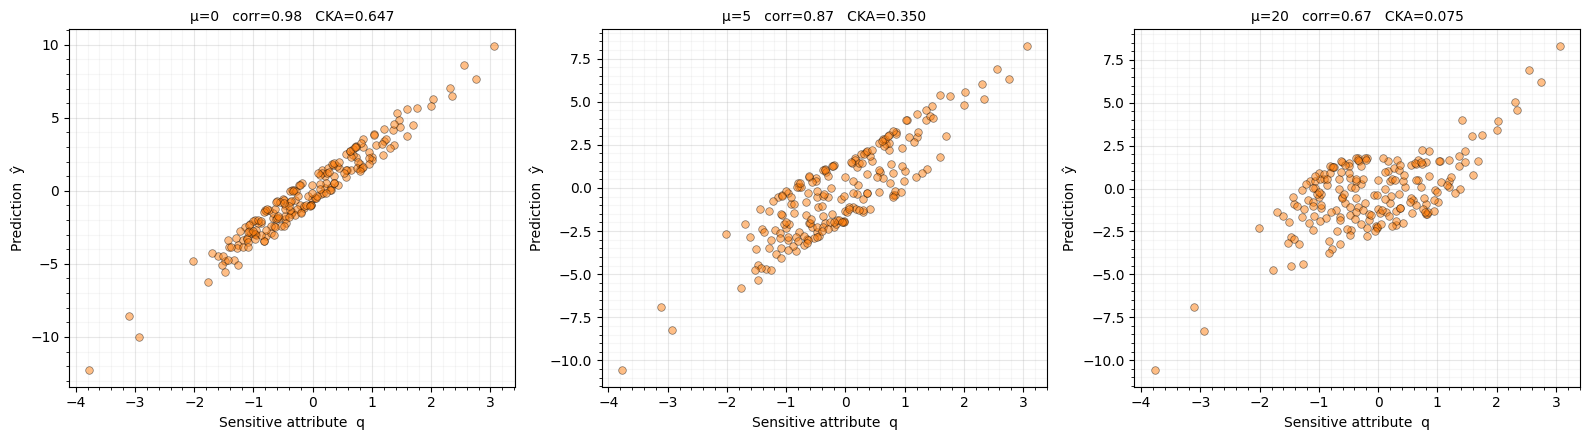

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, mu_sel in zip(axes, [0, 5, 20]):
    idx = mus.index(mu_sel)
    model = FairKernelRidge(sigma=1.0, lam=0.01, mu=mu_sel, sigma_q=1.0)
    model.fit(X, y, q=q, epochs=200, lr=0.005)
    yh = np.array(model.predict(X)).ravel()
    corr = np.corrcoef(yh, q.ravel())[0, 1]
    ax.scatter(q.ravel(), yh, c="C1", **SCATTER_KW)
    ax.set_xlabel("Sensitive attribute  q")
    ax.set_ylabel("Prediction  ŷ")
    ax.set_title(f"μ={mu_sel}   corr={corr:.2f}   CKA={cka_list[idx]:.3f}", fontsize=10)
    style_ax(ax)
plt.tight_layout()
plt.show()

---
## 6  Canonical Plot — Fairness vs Accuracy

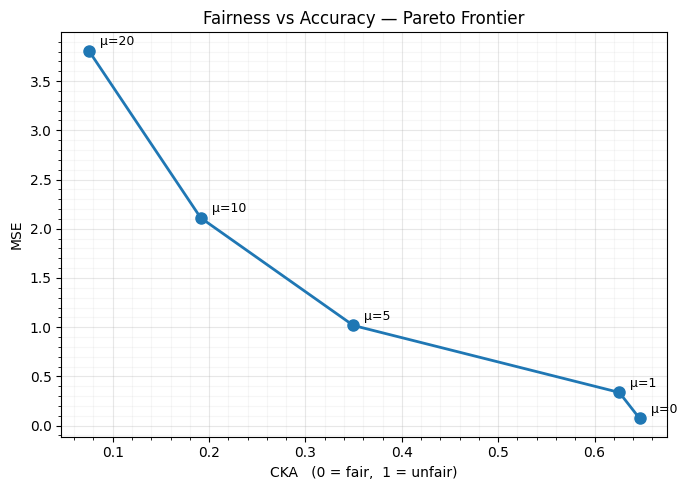

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cka_list, mse_list, "o-", color="C0", lw=2, markersize=8)
for i, mu in enumerate(mus):
    ax.annotate(
        f"μ={mu}",
        (cka_list[i], mse_list[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
    )
ax.set_xlabel("CKA   (0 = fair,  1 = unfair)")
ax.set_ylabel("MSE")
ax.set_title("Fairness vs Accuracy — Pareto Frontier", fontsize=12)
style_ax(ax)
plt.tight_layout()
plt.show()

**Key takeaway**: the `fairkl` API provides composable Keras building
blocks — losses, metrics, kernel layers — alongside ready-to-use
fair models.  The Pareto frontier shows the same fairness-accuracy
trade-off as Parts 1 and 2, confirming consistency.

---

**Next**: [Part 4](tutorial_fair_krr_part4.py) uses Keras Tuner for
automated hyperparameter sweeps over the full search space.